# CS2006: Advanced Programming Projects

## Practical P2: Data analysis and visualisation Python

### Loading the data

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../data/publicmicrodatateachingsample.csv")

### Bar charts for basic requirements

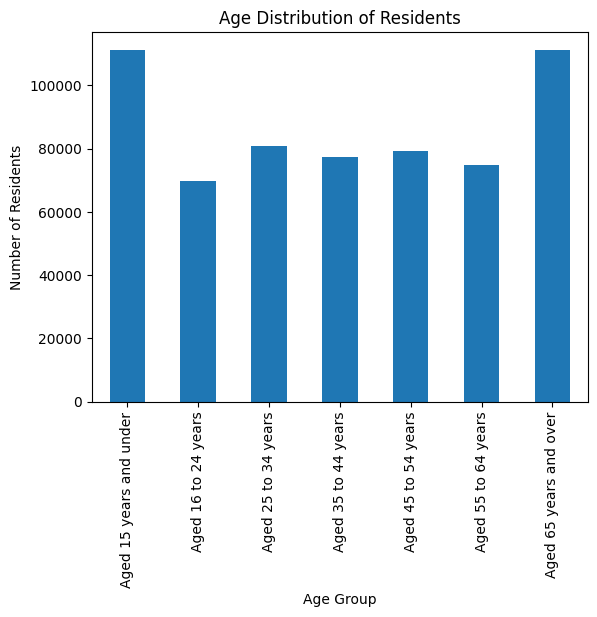

In [25]:
age_counts = df.groupby("resident_age_7d")["resident_age_7d"].count()
age_labels = {
    -8.0: "Does not apply",
     1.0: "Aged 15 years and under",
     2.0: "Aged 16 to 24 years",
     3.0: "Aged 25 to 34 years",
     4.0: "Aged 35 to 44 years",
     5.0: "Aged 45 to 54 years",
     6.0: "Aged 55 to 64 years",
     7.0: "Aged 65 years and over"
}

age_counts.index = age_counts.index.map(age_labels)
age_counts.plot(kind='bar')

plt.title("Age Distribution of Residents")
plt.xlabel("Age Group")
plt.ylabel("Number of Residents")

plt.show()

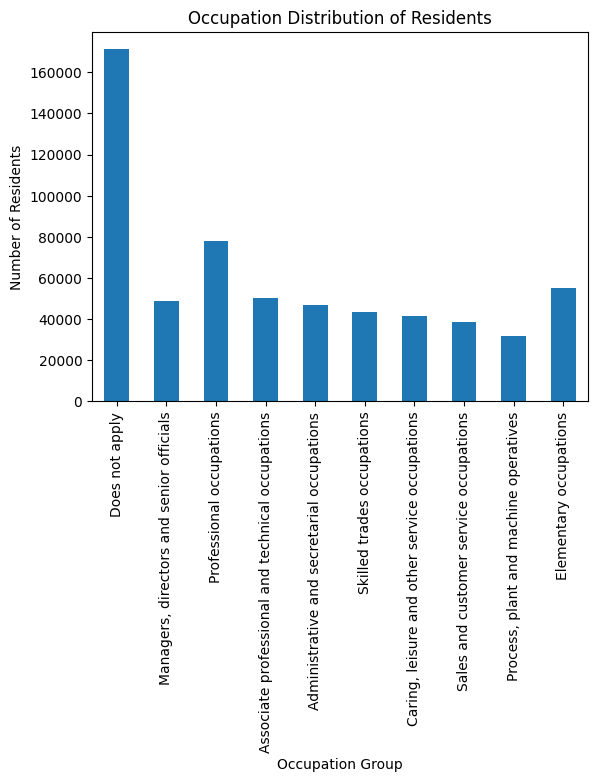

In [27]:
occupation_counts = df.groupby("occupation_10a")["occupation_10a"].count()
occupation_labels = {
    -8.0: "Does not apply",
	 1.0: "Managers, directors and senior officials",
	 2.0: "Professional occupations",
	 3.0: "Associate professional and technical occupations",
	 4.0: "Administrative and secretarial occupations",
	 5.0: "Skilled trades occupations",
	 6.0: "Caring, leisure and other service occupations",
	 7.0: "Sales and customer service occupations",
	 8.0: "Process, plant and machine operatives",
	 9.0: "Elementary occupations"
}

occupation_counts.index = occupation_counts.index.map(occupation_labels)
occupation_counts.plot(kind='bar')

plt.title("Occupation Distribution of Residents")
plt.xlabel("Occupation Group")
plt.ylabel("Number of Residents")

plt.show()

# Easy requirements

See the health counts as a pie chart

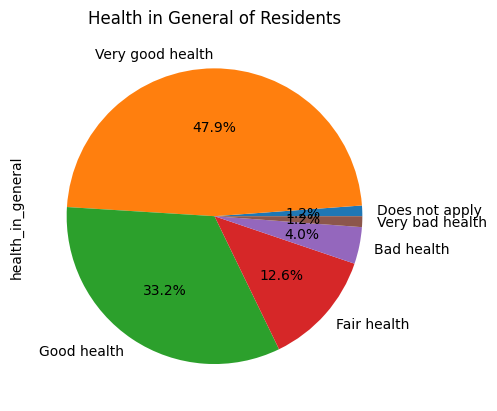

In [34]:
health_counts = df.groupby("health_in_general")["health_in_general"].count()

health_labels = {
    -8.0: "Does not apply",
     1.0: "Very good health",
     2.0: "Good health",
     3.0: "Fair health",
     4.0: "Bad health",
     5.0: "Very bad health"
}

health_counts.index = health_counts.index.map(health_labels)
health_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Health in General of Residents")
plt.show()


We can do a similar idea to get the ethnic counts. 
TODO: MAKE LABELS NOT NUMBERS BUT WHAT THEY REPRESENT

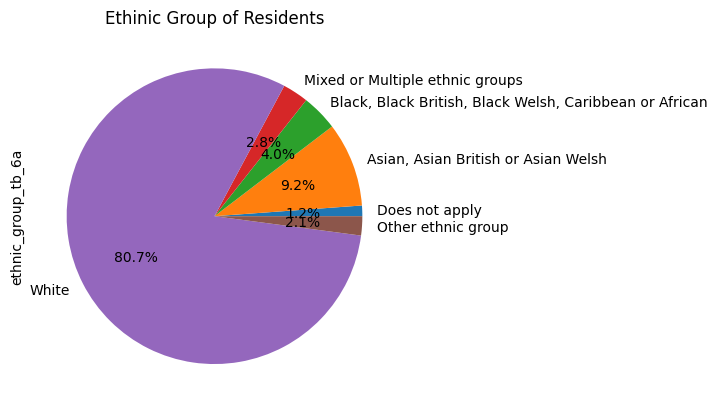

In [35]:
ethnic_counts = df.groupby("ethnic_group_tb_6a")["ethnic_group_tb_6a"].count()

ethnic_counts_labels = {
    -8.0: "Does not apply",
     1.0: "Asian, Asian British or Asian Welsh",
	 2.0: "Black, Black British, Black Welsh, Caribbean or African",
	 3.0: "Mixed or Multiple ethnic groups",
	 4.0: "White",
	 5.0: "Other ethnic group",
}

ethnic_counts.index = ethnic_counts.index.map(ethnic_counts_labels)
ethnic_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Ethinic Group of Residents")
plt.show()

In [36]:
# MEDIUM REQUIRMENTS 
### Group By tables for Hours Worked Vs Industry and Occupation Vs Social Grade

In [37]:
# 1. Number of records by hours by week and industry
hours_industry_table = pd.crosstab(
    df['hours_per_week_worked'],
    df['industry_10a'],
    margins = True,
    margins_name = "Total"
)

print("Records by hours worked and industry:")
display(hours_industry_table)

Records by hours worked and industry:


industry_10a,-8,1,2,3,4,5,6,7,8,9,Total
hours_per_week_worked,,,,,,,,,,,
-8,171052,1178,15425,2423,9366,39277,12049,21086,46666,7610,326132
1,0,188,974,130,1658,8671,1749,5007,7550,2753,28680
2,0,320,1933,321,2610,14683,3160,7732,20547,3108,54414
3,0,986,15231,3017,15781,26928,17830,29368,49667,5795,164603
4,0,908,2132,661,4109,4915,3950,5786,7091,970,30522
Total,171052,3580,35695,6552,33524,94474,38738,68979,131521,20236,604351


In [38]:
# 2. Number of records by occupation and approximate social grade
occupation_grade_table = pd.crosstab(
    df['occupation_10a'],
    df['approx_social_grade'],
    margins = True,
    margins_name = "Total"
)

print("\nRecords by occupation and social grade:")
display(occupation_grade_table)


Records by occupation and social grade:


approx_social_grade,-8,1,2,3,4,Total
occupation_10a,,,,,,
-8,20691,32890,43001,29483,44987,171052
1,11244,15978,16226,3151,1996,48595
2,17729,36545,16690,4201,2738,77903
3,9606,9472,22578,5716,2826,50198
4,16670,4861,17733,4254,3123,46641
5,11878,2112,6274,18586,4479,43329
6,8679,3216,9338,11799,8327,41359
7,10547,2855,10420,5186,9501,38509
8,9312,1214,4175,8688,8350,31739


In [39]:
# Extra addition to the above - Heatmap 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(
    pd.crosstab(df['hours_per_week_worked'], df['industry_10a']),
    annot=True, fmt='d', cmap='Blues'
)
plt.title('Hours Worked vs Industry')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(
    pd.crosstab(df['occupation_10a'], df['approx_social_grade']),
    annot=True, fmt='d', cmap='Reds'
)
plt.title('Occupation vs Social Grade')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
## Medium Requirments 2
## Ecomomic Activitiy Analysis

Economically active people by age:


resident_age_7d
2     60557
3     74958
4     71856
5     71393
6     65372
7    107253
Name: resident_age_7d, dtype: int64

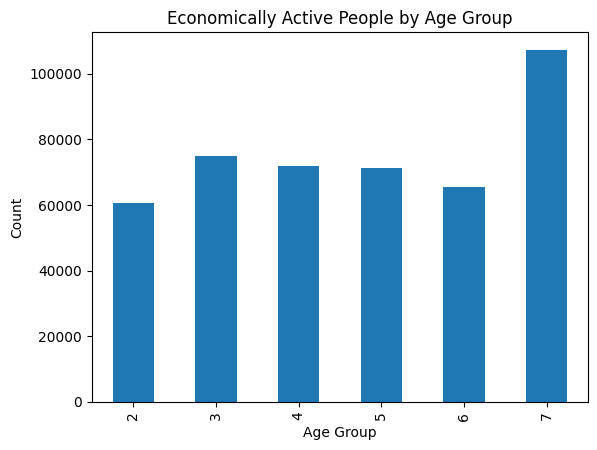

In [ ]:
# 1. Economically active people by age
economic_active = df[df['economic_activity_status_10m'].isin([1, 2, 3, 4, 5, 6, 7])]  # Active status codes 1,2,3,4,5,6,7
active_by_age = economic_active.groupby('resident_age_7d')['resident_age_7d'].count()

print("Economically active people by age:")
display(active_by_age)

# Plot
active_by_age.plot(kind = 'bar', title = 'Economically Active People by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

\Ecnomically inactive people by health status:


health_in_general
1    6043
2    8171
3    9263
4    8849
5    3520
Name: health_in_general, dtype: int64

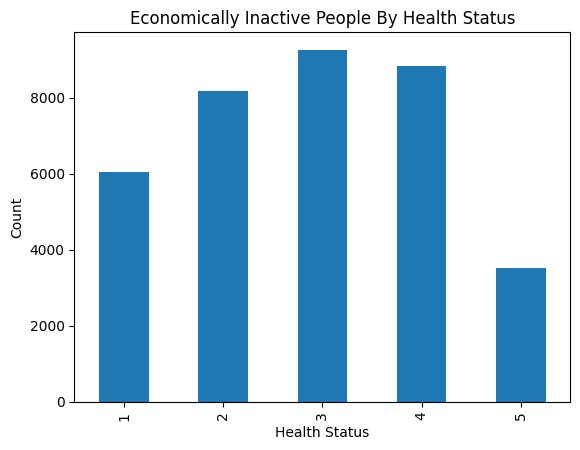

In [ ]:
# 2. Economically inactive poeple by health status
economic_inactive = df[df['economic_activity_status_10m'].isin([8,9])] # Inactive status code 8,9
inactive_by_health = economic_inactive.groupby('health_in_general')['health_in_general'].count()

print("\Ecnomically inactive people by health status:")
display(inactive_by_health)

# Plot
inactive_by_health.plot(kind = 'bar', title = 'Economically Inactive People By Health Status')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.show()


Working hours per week for students:


hours_per_week_worked
-8    31049
 1     4370
 2     2170
 3     1500
 4      169
Name: count, dtype: int64

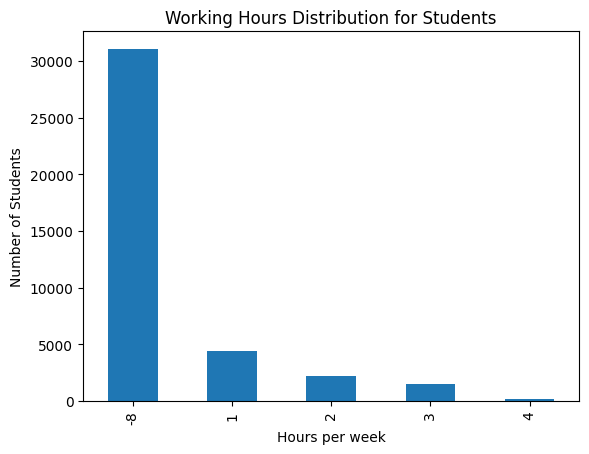

In [ ]:
# 3. Working hours for students
# Codes 4 and 6 in Economic Activity
students = df[df['economic_activity_status_10m'].isin([4,6])]   # Codes 4,6 are for students
student_hours = students['hours_per_week_worked'].value_counts().sort_index()

print("\nWorking hours per week for students:")
display(student_hours)

# Plot
student_hours.plot(kind = 'bar', title = 'Working Hours Distribution for Students')
plt.xlabel('Hours per week')
plt.ylabel('Number of Students')
plt.show()
